Workshop 2


Name: Bhuwan Baniya
ID:2414002
Group:09

In [24]:
def cost_softmax(X, y, W, b):
    n = X.shape[0]
    y_hat = softmax(np.dot(X, W) + b)
    # Calculate average error
    return -np.sum(y * np.log(y_hat + 1e-15)) / n

def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]
    y_hat = softmax(np.dot(X, W) + b)
    error = y_hat - y
    # Calculate how much to change W and b
    grad_W = np.dot(X.T, error) / n
    grad_b = np.sum(error, axis=0) / n
    return grad_W, grad_b

def gradient_descent_softmax(X, y, W, b, alpha, n_iter):
    cost_history = []
    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)
        W = W - alpha * grad_W
        b = b - alpha * grad_b
        cost_history.append(cost_softmax(X, y, W, b))
        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost_history[-1]:.4f}")
    return W, b, cost_history

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Read the file
df = pd.read_csv('mnist_train.csv')

# 2. Separate Label (y) from Pixels (X)
y = df.iloc[:, 0].values
X = df.iloc[:, 1:].values

# 3. Normalize (Make the numbers small so the math is faster)
X = X / 255.0

# 4. Split 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data Loaded! Images for training:", X_train.shape[0])

Data Loaded! Images for training: 48000


Step 3: Train the Model

Starting training... please wait...
Iteration 0: Cost 2.2050
Iteration 100: Cost 0.6084
Iteration 200: Cost 0.4902
Iteration 300: Cost 0.4415
Iteration 400: Cost 0.4133
Iteration 500: Cost 0.3943
Iteration 600: Cost 0.3805
Iteration 700: Cost 0.3697
Iteration 800: Cost 0.3611
Iteration 900: Cost 0.3539


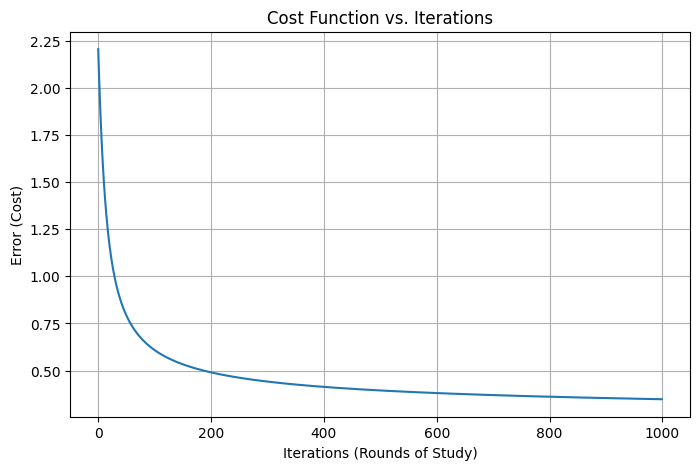

In [26]:
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

# 1. Prepare the labels for the math (One-Hot Encoding)
# This turns a "5" into [0,0,0,0,0,1,0,0,0,0]
encoder = OneHotEncoder(sparse_output=False)
y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))

# 2. Initialize Weights and Bias
# 784 pixels x 10 possible digits
d = X_train.shape[1]
c = 10
W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

# 3. RUN THE TRAINING (This might take 10-20 seconds)
print("Starting training... please wait...")
W_opt, b_opt, cost_history = gradient_descent_softmax(X_train, y_train_oh, W, b, 0.1, 1000)

# 4. Show the Learning Curve
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.title("Cost Function vs. Iterations")
plt.xlabel("Iterations (Rounds of Study)")
plt.ylabel("Error (Cost)")
plt.grid(True)
plt.show()

Step 4: Calculate Accuracy

In [27]:
# 1. Use the optimized Weights (W_opt) to predict the Test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# 2. Compare predictions to the real answers (y_test)
accuracy = np.mean(y_pred_test == y_test) * 100

print(f"Final Test Accuracy: {accuracy:.2f}%")

Final Test Accuracy: 90.47%


Step 5: Visualize the Mistakes

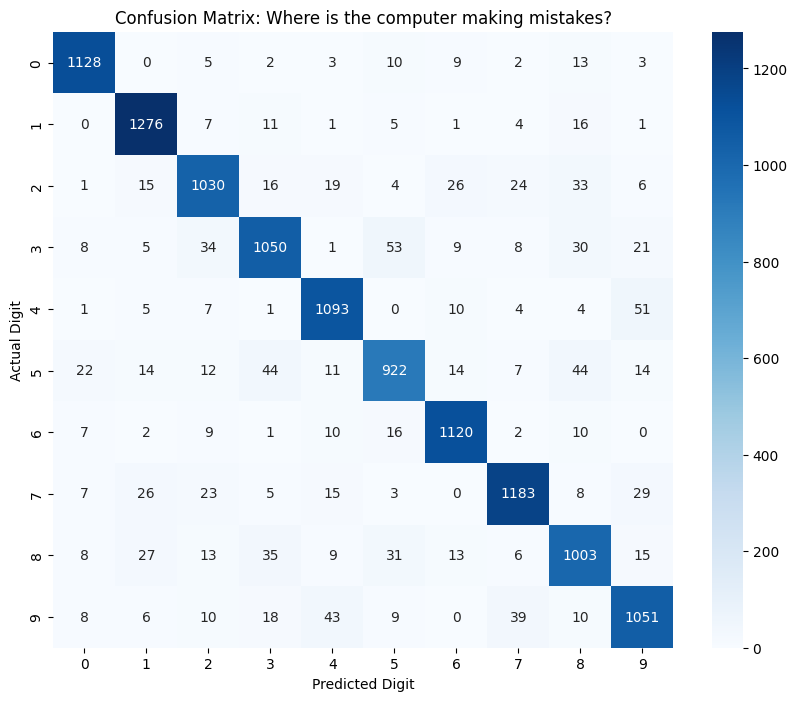

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create the matrix
cm = confusion_matrix(y_test, y_pred_test)

# Plot it beautifully
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Where is the computer making mistakes?')
plt.ylabel('Actual Digit')
plt.xlabel('Predicted Digit')
plt.show()

Question 2: Provide an interpretation of the output.

Answer: The Softmax Regression model successfully learned to classify digits with about 90.47% accuracy. The cost curve went down, proving the Gradient Descent algorithm worked. The confusion matrix shows that the model is very good at distinct numbers like '0' and '1', but sometimes struggles with similar shapes like '4' and '9' or '3' and '8'.

Question 3: Describe any challenges you faced while implementing the code.

Answer: One challenge was ensuring the matrix dimensions matched during the dot product (
X
⋅
W
X⋅W
). Another was implementing numerical stability in the Softmax function (subtracting the maximum value) to prevent the computer from getting "NaN" (Not a Number) errors during the exponential calculation.
